# Lab 1 : Understanding the Olist E-commerce Dataset

# Import Required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows",100)

# Define Dataset Path

In [5]:
DATA_DIR = Path("../data/raw")

In [6]:
DATA_DIR.exists()

True

In [7]:
for  file in DATA_DIR.glob("*.csv"):
    print (file.name)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


# Load All Datasets

In [23]:
customers = pd.read_csv(DATA_DIR/"olist_customers_dataset.csv")
geolocation = pd.read_csv(DATA_DIR/"olist_geolocation_dataset.csv")
order_items = pd.read_csv(DATA_DIR/"olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR/"olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR/"olist_order_reviews_dataset.csv")
orders = pd.read_csv(DATA_DIR/"olist_orders_dataset.csv")
products = pd.read_csv(DATA_DIR/"olist_products_dataset.csv")
sellers = pd.read_csv(DATA_DIR/"olist_sellers_dataset.csv")
category_translation = pd.read_csv(
    DATA_DIR/"product_category_name_translation.csv"
)



In [9]:
tables = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

print("All datasets loaded successfully :) .")

All datasets loaded successfully :) .


# 6.Display Shape of Each Table


In [10]:
for name, df in tables.items():
    print(f"{name:25} Rows = {df.shape[0]:8}   Columns = {df.shape[1]}")

customers                 Rows =    99441   Columns = 5
geolocation               Rows =  1000163   Columns = 5
order_items               Rows =   112650   Columns = 7
payments                  Rows =   103886   Columns = 5
reviews                   Rows =    99224   Columns = 7
orders                    Rows =    99441   Columns = 8
products                  Rows =    32951   Columns = 9
sellers                   Rows =     3095   Columns = 4
category_translation      Rows =       71   Columns = 2


# 7. Preview Each Table

In [22]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [12]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [14]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [15]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [16]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [17]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [18]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [19]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


# 8.Inspect Data Types

In [21]:
customers.info()
for name , df in tables.items():
    print("\n" + "="*80)
    print(name.upper())
    print("="*80)
    print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB

CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes:

In [ ]:
# to identify which columns are numeric , categorial , dates and identifiers

In [24]:
for name, df in tables.items():
    print("\n", name)
    print(df.dtypes)


 customers
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

 geolocation
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object

 order_items
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

 payments
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

 reviews
review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_co

# Create Dataset Summary

In [26]:
def summarize_table(name, df):
    return {
        "table_name": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": df.isnull().sum().sum(),
        "duplicate_rows": df.duplicated().sum()
    }

summary = pd.DataFrame(
    [summarize_table(name, df) for name, df in tables.items()]
)

summary

,table_name,rows,columns,missing_values,duplicate_rows
0,customers,99441,5,0,0
1,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
4,reviews,99224,7,145903,0
5,orders,99441,8,4908,0
6,products,32951,9,2448,0
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [ ]:
# saving this summary


In [28]:
summary.to_csv(
    "../reports/lab01_dataset_summary.csv",
    index=False
)

print("Dataset summary saved. yay!")

Dataset summary saved. yay!


# 10.Missing Value Analysis

In [30]:
def missing_value_summary(df):

    missing_count = df.isnull().sum()

    missing_percent = (
        missing_count / len(df)
    ) * 100

    result = pd.DataFrame({
        "Missing Count": missing_count,
        "Missing Percentage": missing_percent
    })

    return result[result["Missing Count"]>0]\
            .sort_values(
                by="Missing Percentage",
                ascending=False
            )

In [ ]:
# we will run this for every table

In [31]:
for name, df in tables.items():

    print("\n" + "="*80)
    print(name.upper())
    print("="*80)

    display(missing_value_summary(df))


CUSTOMERS


,Missing Count,Missing Percentage



GEOLOCATION


,Missing Count,Missing Percentage



ORDER_ITEMS


...

,Missing Count,Missing Percentage
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070



SELLERS


,Missing Count,Missing Percentage



CATEGORY_TRANSLATION


,Missing Count,Missing Percentage


# 11 . Duplicate Record Analysis

In [32]:
for name, df in tables.items():

    duplicate_count = df.duplicated().sum()

    print(f"{name:25} {duplicate_count} duplicate rows")

customers                 0 duplicate rows
geolocation               261831 duplicate rows
order_items               0 duplicate rows
payments                  0 duplicate rows
reviews                   0 duplicate rows
orders                    0 duplicate rows
products                  0 duplicate rows
sellers                   0 duplicate rows
category_translation      0 duplicate rows


# 12 . Explore Orders Table

In [33]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [34]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [35]:
# plotting order status distribution

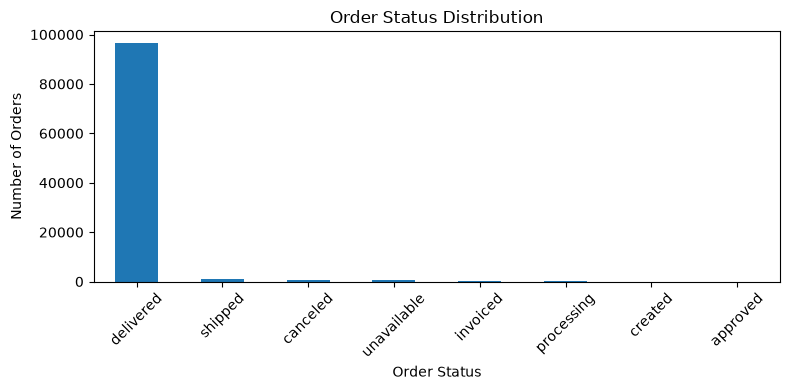

In [36]:
plt.figure(figsize=(8,4))

orders["order_status"].value_counts().plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../figures/lab01_order_status_distribution.png")

plt.show()

# 13 .Explore Reviews Table

In [37]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [38]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

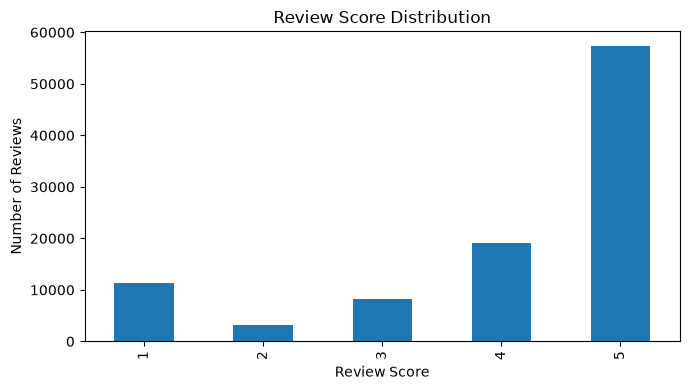

In [39]:
plt.figure(figsize=(7,4))

reviews["review_score"]\
.value_counts()\
.sort_index()\
.plot(kind="bar")

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

# 14.Explore Payments Table

In [40]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [41]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

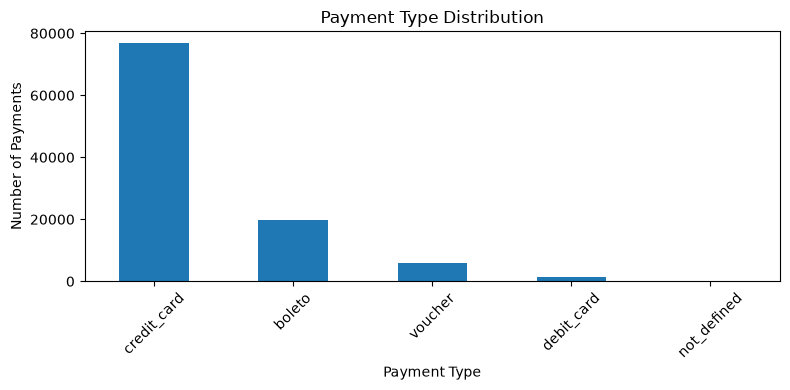

In [42]:
plt.figure(figsize=(8,4))

payments["payment_type"]\
.value_counts()\
.plot(kind="bar")

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# 15.Explore Products Table

In [43]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [44]:
# check missing values 
missing_value_summary(products)

,Missing Count,Missing Percentage
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


In [45]:
#check categories
products["product_category_name"].nunique()

73

In [46]:
# Top categories in product
products["product_category_name"]\
.value_counts()\
.head(10)

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

# 16.Explore Customers Table

In [47]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [48]:
# top customers states
customers["customer_state"]\
.value_counts()\
.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

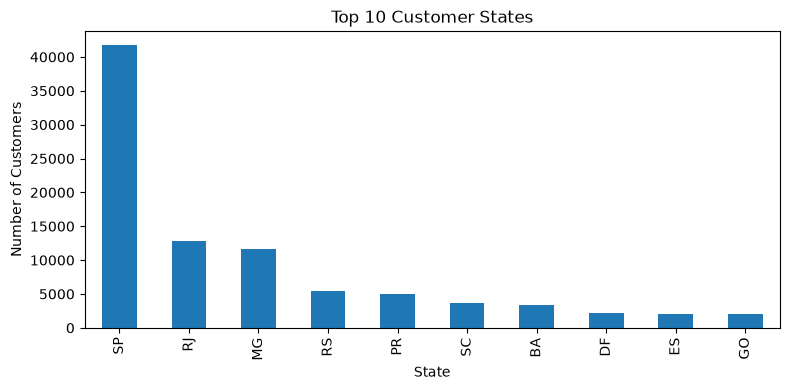

In [50]:
# top 10 customer states
plt.figure(figsize=(8,4))

customers["customer_state"]\
.value_counts()\
.head(10)\
.plot(kind="bar")

plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

# 17.Initial Business Questions

# Question 1 : How many unique customers are present?

In [51]:
customers["customer_unique_id"].nunique()

96096

# Question 2 : How many orders are present ?

In [53]:
orders["order_id"].nunique()

99441

# Question 3 : What are the most common order statuses?

In [54]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

# Question 4 : What are the most common payment methods ?

In [55]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

# Question 5 : What is the average review score ?

In [56]:
reviews["review_score"].mean()

np.float64(4.08642062404257)

# Question 6 : Which states have the most customers ?

In [58]:
customers["customer_state"]\
.value_counts()\
.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

# 19 . Creating initial data dictionary
# Lab 1 - Data Dictionary

## 1. Customers Table

| Column Name | Data Type | Description | Example |
|-------------|-----------|-------------|---------|
| customer_id | String | Unique customer identifier for each order | 06b8999e2fba1a1fbc88172c00ba8bc7 |
| customer_unique_id | String | Unique customer across all orders | 861eff4711a542e4b93843c6dd7febb0 |
| customer_zip_code_prefix | Integer | Customer ZIP code prefix | 14409 |
| customer_city | String | Customer city | franca |
| customer_state | String | Customer state | SP |

---

## 2. Orders Table

| Column Name | Data Type | Description | Example |
|-------------|-----------|-------------|---------|
| order_id | String | Unique order identifier | e481f51cbdc54678b7cc49136f2d6af7 |
| customer_id | String | Customer who placed the order | 9ef432eb6251297304e76186b10a928d |
| order_status | String | Current order status | delivered |
| order_purchase_timestamp | DateTime | Purchase date and time | 2017-10-02 10:56:33 |
| order_approved_at | DateTime | Payment approval time | 2017-10-02 11:07:15 |
| order_delivered_customer_date | DateTime | Delivery date | 2017-10-10 21:25:13 |

---

## 3. Order Items Table

| Column Name | Data Type | Description | Example |
|-------------|-----------|-------------|---------|
| order_id | String | Order identifier | 00010242fe8c5a6d1ba2dd792cb16214 |
| order_item_id | Integer | Item number within an order | 1 |
| product_id | String | Product identifier | 4244733e06e7ecb4970a6e2683c13e61 |
| seller_id | String | Seller identifier | 48436dade18ac8b2bce089ec2a041202 |
| shipping_limit_date | DateTime | Last shipping date | 2017-09-19 09:45:35 |
| price | Float | Product price | 58.90 |
| freight_value | Float | Shipping cost | 13.29 |
